# Векторизация текста


In [305]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize
from gensim.models.word2vec import Word2Vec
from gensim.models.doc2vec import TaggedDocument, Doc2Vec
import gensim.downloader as api
from scipy.spatial.distance import cdist
np.random.seed(42)

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords', quiet=True)

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet', quiet=True)

sns.set_palette("husl")


[nltk_data] Error loading wordnet: <urlopen error [WinError 10060]
[nltk_data]     Попытка установить соединение была безуспешной, т.к.
[nltk_data]     от другого компьютера за требуемое время не получен
[nltk_data]     нужный отклик, или было разорвано уже установленное
[nltk_data]     соединение из-за неверного отклика уже подключенного
[nltk_data]     компьютера>


Для демонстрации используем датасет **20 Newsgroups** - уже немного знакомый нам набор данных для задач текстовой классификации. Он содержит около 20,000 новостных сообщений, разделенных на 20 категорий, хорошо сбалансирован.


In [306]:
categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']

print("Загрузка данных 20 Newsgroups...")
newsgroups_train = fetch_20newsgroups(
    subset='train',
    categories=categories,
    shuffle=True,
    random_state=42,
    remove=('headers', 'footers', 'quotes')
)

newsgroups_test = fetch_20newsgroups(
    subset='test',
    categories=categories,
    shuffle=True,
    random_state=42,
    remove=('headers', 'footers', 'quotes')
)

print(f"Обучающая выборка: {len(newsgroups_train.data)} документов")
print(f"Тестовая выборка: {len(newsgroups_test.data)} документов")
print(f"Количество категорий: {len(categories)}")
print(f"\nКатегории: {categories}")


Загрузка данных 20 Newsgroups...
Обучающая выборка: 2257 документов
Тестовая выборка: 1502 документов
Количество категорий: 4

Категории: ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']


## Предобработка текста

Текст требует специальной предобработки перед использованием в моделях машинного обучения. Основные шаги:

1. **Токенизация** - разбиение текста на отдельные слова (токены)
2. **Нормализация** - приведение к нижнему регистру
3. **Удаление стоп-слов** - удаление часто встречающихся, но не несущих смысловой нагрузки слов (или мата, например)
4. **Лемматизация/Стемминг** - приведение слов к их базовой форме

Лемматизация - процесс приведения слова к его нормальной форме (лемме):
- для существительных - именительный падеж, единственное число;
- для прилагательных - именительный падеж, единственное число, мужской род; 
- для глаголов, причастий, деепричастий - глагол в инфинитиве.
Для лемматизации на русском языке есть библиотека pymorphy3.

Stemming – это процесс нахождения основы слова. В результате применения данной процедуры однокоренные слова, как правило, преобразуются к одинаковому виду. 
Snowball – фрэймворк для написания алгоритмов стемминга. Алгоритмы стемминга отличаются для разных языков и используют знания о конкретном языке – списки окончаний для разных чистей речи, разных склонений и т.д. Пример алгоритма для русского языка – Russian stemming.


In [307]:
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

example_text = newsgroups_train.data[0]
print("Исходный текст (первые 300 символов):")
print(example_text[:300])

Исходный текст (первые 300 символов):
Does anyone know of a good way (standard PC application/PD utility) to
convert tif/img/tga files into LaserJet III format.  We would also like to
do the same, converting to HPGL (HP plotter) files.

Please email any response.

Is this the correct group?

Thanks in advance.  Michael.


In [308]:
text = example_text.lower()
text = re.sub(r'[^a-zA-Z\s]', '', text)
tokens = word_tokenize(text)
tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
print(tokens)

['anyone', 'know', 'good', 'way', 'standard', 'applicationpd', 'utility', 'convert', 'tifimgtga', 'files', 'laserjet', 'iii', 'format', 'would', 'also', 'like', 'converting', 'hpgl', 'plotter', 'files', 'please', 'email', 'response', 'correct', 'group', 'thanks', 'advance', 'michael']


In [309]:
tokens = [lemmatizer.lemmatize(word) for word in tokens]
print(tokens)

['anyone', 'know', 'good', 'way', 'standard', 'applicationpd', 'utility', 'convert', 'tifimgtga', 'file', 'laserjet', 'iii', 'format', 'would', 'also', 'like', 'converting', 'hpgl', 'plotter', 'file', 'please', 'email', 'response', 'correct', 'group', 'thanks', 'advance', 'michael']


In [310]:
tokens = [stemmer.stem(word) for word in tokens]
print(tokens)

['anyon', 'know', 'good', 'way', 'standard', 'applicationpd', 'util', 'convert', 'tifimgtga', 'file', 'laserjet', 'iii', 'format', 'would', 'also', 'like', 'convert', 'hpgl', 'plotter', 'file', 'pleas', 'email', 'respons', 'correct', 'group', 'thank', 'advanc', 'michael']


In [311]:

def preprocess_text(text: str, use_lemmatization: bool = True) -> str:
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    
    if use_lemmatization:
        tokens = [lemmatizer.lemmatize(word) for word in tokens]
    else:
        tokens = [stemmer.stem(word) for word in tokens]
    
    return ' '.join(tokens)

print("После предобработки:")
processed = preprocess_text(example_text)
print(processed[:300])


После предобработки:
anyone know good way standard applicationpd utility convert tifimgtga file laserjet iii format would also like converting hpgl plotter file please email response correct group thanks advance michael


##  Векторизация текста
ML модели работают с числовыми данными, поэтому текст нужно преобразовать в числовые векторы. Рассмотрим несколько основных подходов:

**Bag-of-Words** - простейший способ представления текста. Каждый документ в нем представляется как вектор, где каждая позиция соответствует определенному слову из словаря, а значение - частоте появления этого слова в документе.
Это наиболее простой метод, но он приводит к потере информации о порядке слов и приводит к очень разреженным векторам.



In [312]:
print("Предобработка текстов...")
X_train_processed = [preprocess_text(text) for text in newsgroups_train.data[:1000]]
X_test_processed = [preprocess_text(text) for text in newsgroups_test.data[:500]]

print(f"Обработано {len(X_train_processed)} обучающих и {len(X_test_processed)} тестовых документов")


Предобработка текстов...
Обработано 1000 обучающих и 500 тестовых документов


In [313]:
bow_vectorizer = CountVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95
)

print("Создание Bag-of-Words представления...")
X_train_bow = bow_vectorizer.fit_transform(X_train_processed)
X_test_bow = bow_vectorizer.transform(X_test_processed)

print(f"Размерность обучающей выборки: {X_train_bow.shape}")
print(f"Размерность тестовой выборки: {X_test_bow.shape}")
print(f"Размер словаря: {len(bow_vectorizer.vocabulary_)}")

print(f"\nПримеры слов из словаря (первые 20):")
print(list(bow_vectorizer.vocabulary_.keys())[:20])


Создание Bag-of-Words представления...
Размерность обучающей выборки: (1000, 5000)
Размерность тестовой выборки: (500, 5000)
Размер словаря: 5000

Примеры слов из словаря (первые 20):
['anyone', 'know', 'good', 'way', 'standard', 'utility', 'convert', 'file', 'iii', 'format', 'would', 'also', 'like', 'converting', 'plotter', 'please', 'email', 'response', 'correct', 'group']


In [314]:
doc_vector = X_train_bow[0].toarray()[0]
non_zero_indices = np.where(doc_vector > 0)[0]

print(f"Документ содержит {len(non_zero_indices)} уникальных слов из словаря")
print(f"Общее количество слов в документе: {doc_vector.sum()}")

feature_names = bow_vectorizer.get_feature_names_out()
top_words_idx = np.argsort(doc_vector)[-10:][::-1]
print("\nТоп-10 слов в документе:")
for idx in top_words_idx:
    if doc_vector[idx] > 0:
        print(f"  {feature_names[idx]}: {int(doc_vector[idx])}")


Документ содержит 23 уникальных слов из словаря
Общее количество слов в документе: 24

Топ-10 слов в документе:
  file: 2
  thanks: 1
  converting: 1
  anyone: 1
  plotter: 1
  advance: 1
  would: 1
  response: 1
  please: 1
  like: 1


**Задание**:  Постройте bag-of-words для слов без лемматизации и стемминга (а также только с лемматизацией). Как их отсутствие повлияет на размеры словаря (попробуйте не обрезать) и встречаемость слов?

In [ ]:
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction import text
from nltk.stem import WordNetLemmatizer, PorterStemmer

stop_words = text.ENGLISH_STOP_WORDS

lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

def simple_tokenize(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    tokens = text.split() 
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    return tokens

def preprocess_raw(text):
    tokens = simple_tokenize(text)
    return ' '.join(tokens)

def preprocess_lemma_only(text):
    tokens = simple_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

def preprocess_full(text):
    tokens = simple_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    tokens = [stemmer.stem(w) for w in tokens]
    return ' '.join(tokens)

subset = newsgroups_train.data[:100]

texts_raw   = [preprocess_raw(t)        for t in subset]
texts_lemma = [preprocess_lemma_only(t) for t in subset]
texts_full  = [preprocess_full(t)       for t in subset]

texts_raw   = [t for t in texts_raw if t.strip()]
texts_lemma = [t for t in texts_lemma if t.strip()]
texts_full  = [t for t in texts_full if t.strip()]

for label, texts in [
    ('Без предобработки',       texts_raw),
    ('Только лемматизация',     texts_lemma),
    ('Лемматизация + стемминг', texts_full)
]:
    cv = CountVectorizer()
    X = cv.fit_transform(texts)

    vocab_size = len(cv.vocabulary_)

    print(f'{label}: {vocab_size}')

Без предобработки: 2764
Только лемматизация: 2569
Лемматизация + стемминг: 2200


**Ответ:**

Без лемматизации и стемминга словарь получается больше, так как разные формы одного слова
(run, runs, running) считаются разными токенами.

При использовании только лемматизации формы слов приводятся к нормальной форме,
поэтому размер словаря уменьшается.

Общее количество токенов и средняя длина документов при этом остаются практически
одинаковыми, так как слова не удаляются, а только преобразуются.

Встречаемость отдельных слов изменяется: частоты разных форм одного слова
объединяются в одну, поэтому частота лемматизированных слов становится выше.

### TF-IDF (Term Frequency-Inverse Document Frequency)

**TF-IDF** - более продвинутый способ векторизации, который учитывает не только частоту слова в документе, но и его важность в корпусе.

- **TF (Term Frequency)**: частота слова в документе.

- **IDF (Inverse Document Frequency)**: обратная частота документа - мера того, насколько редким является слово в корпусе: 
$\text{IDF}(t) = \log\frac{N}{\text{df}(t)}$, где $N$ - общее количество документов, $\text{df}(t)$ - количество документов, содержащих термин $t$.

**Формула:**
$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$



In [316]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_processed)
X_test_tfidf = tfidf_vectorizer.transform(X_test_processed)

print(f"Размерность обучающей выборки: {X_train_tfidf.shape}")
print(f"Размерность тестовой выборки: {X_test_tfidf.shape}")

feature_names = tfidf_vectorizer.get_feature_names_out()
idf_values = tfidf_vectorizer.idf_

top_idf_idx = np.argsort(idf_values)[-20:][::-1]
print("\nТоп-20 слов с наибольшим IDF:")
for idx in top_idf_idx:
    print(f"  {feature_names[idx]}: IDF = {idf_values[idx]:.3f}")


Размерность обучающей выборки: (1000, 5000)
Размерность тестовой выборки: (500, 5000)

Топ-20 слов с наибольшим IDF:
  abc: IDF = 6.810
  scsi: IDF = 6.810
  sharp: IDF = 6.810
  shalala said: IDF = 6.810
  shalala: IDF = 6.810
  sgi machine: IDF = 6.810
  sexist: IDF = 6.810
  sexism: IDF = 6.810
  drs: IDF = 6.810
  serial port: IDF = 6.810
  ds: IDF = 6.810
  dsp: IDF = 6.810
  septuagint: IDF = 6.810
  dyer: IDF = 6.810
  sensing: IDF = 6.810
  sence: IDF = 6.810
  elaine: IDF = 6.810
  select: IDF = 6.810
  embarrassed: IDF = 6.810
  showcase: IDF = 6.810


In [317]:
mask = [i for i, el in enumerate(X_train_processed) if el.find("hicolor") > -1 ]

In [318]:
X_train_processed[123]

'cut limit azt efficacy suggest using drug either sequentially drug kind aid treatment cocktail combining number drug fight virus treating people azt alone doesnt happen real world anymore said mark jacobson university californiasan francisco also recent finding indicating hiv replicates rapidly lymph node infection physician may begin pushing even harder early treatment hivinfected patient new infectious disease push american medical news vol center disease control launch worldwide network track spread infectious disease detect drugresistant new strain time help prevent spread network expected cost million million essential part clinton administration health reform plan according cdc outside expert plan require cdc enhance surveillance disease united state establish facility across world track disease april nih plan begin aid drug trial earlier stage nature vol macilwain colin hicnet medical newsletter page volume number april national institute health announced start treating hivposi

Задание: Поиграйте с настройками для TF-IDF. Что будет, если не использовать idf (use_idf=False), как изменятся эмбеддинги? Что будет, если использовать sublinear_tf=True? Что будет ,если не нормализовать векторы? Можете сравнивать результаты через визуализации или численные характеристики.

In [319]:
# Задание: эксперименты с настройками TF-IDF
from sklearn.metrics.pairwise import cosine_similarity
configs = {
    'Базовый TF-IDF':            dict(use_idf=True,  sublinear_tf=False, norm='l2'),
    'use_idf=False (только TF)': dict(use_idf=False, sublinear_tf=False, norm='l2'),
    'sublinear_tf=True':         dict(use_idf=True,  sublinear_tf=True,  norm='l2'),
    'norm=None (без норм.)':     dict(use_idf=True,  sublinear_tf=False, norm=None),
}

sample_texts = X_train_processed[:200]

print(f"{'Конфигурация':30s} | {'Макс знач':10s} | {'Мин >0':8s} | {'Средн ненул':12s} | Косин.схожесть[0,1]")
print('-' * 85)

for name, params in configs.items():
    vec = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.95, **params)
    X = vec.fit_transform(sample_texts).toarray()
    nonzero = X[X > 0]
    sim = cosine_similarity(X[0:1], X[1:2])[0, 0]
    print(f'{name:30s} | {X.max():10.4f} | {nonzero.min():8.4f} | {nonzero.mean():12.4f} | {sim:.4f}')

Конфигурация                   | Макс знач  | Мин >0   | Средн ненул  | Косин.схожесть[0,1]
-------------------------------------------------------------------------------------
Базовый TF-IDF                 |     0.7577 |   0.0042 |       0.1131 | 0.0305
use_idf=False (только TF)      |     0.7071 |   0.0090 |       0.1141 | 0.0748
sublinear_tf=True              |     0.7577 |   0.0107 |       0.1223 | 0.0362
norm=None (без норм.)          |   143.7940 |   2.0128 |       5.8449 | 0.0305


### Объяснение

**use_idf=False**  
Веса = только TF, без штрафа за частые слова.  
Частые слова (the, said) получают высокий вес - хуже для классификации.

---

**sublinear_tf=True**  
TF заменяется на `1 + log(TF)`.  
Сжимает диапазон значений: слово, встретившееся 100 раз, не получает вес в 100 раз больше, чем встретившееся 1 раз.  
Уменьшает влияние повторяющихся слов и часто улучшает качество классификации текстов.

---

**norm=None**  
Векторы не нормированы по длине.  
Длинные документы получают большие значения -> косинусное сходство смещается в пользу длинных текстов.  
Важно нормировать при сравнении документов.

##  Эмбеддинги слов

**Эмбеддинги слов** (word embeddings) - плотные векторы фиксированной размерности, в которых семантически близкие слова оказываются близки в пространстве. В отличие от Bag-of-Words и TF-IDF это распределённое представление (distributed representation): векторы плотные, а не разреженные, и кодируют контекстное употребление слова.

Подробнее см. в [word_embeddings.md](word_embeddings.md).

### Word2Vec

**Word2Vec** учит векторные представления слов, предсказывая контекст по слову или слово по контексту. Варианты:

- **Skip-gram**: по центральному слову предсказываем слова в окне (контекст).
- **CBOW** (Continuous Bag of Words): по сумме векторов контекста предсказываем центральное слово.

Цель обучения - максимизация правдоподобия; на практике используют **negative sampling** (несколько случайных «негативных» слов вместо полного softmax по словарю). 

Основные параметры: `vector_size` (размерность), `window` (размер окна), `min_count`, `sg` (1 = skip-gram, 0 = CBOW), `negative` (число негативных примеров), `epochs`.

Обучим такую модель.

In [320]:
sentences = [text.split() for text in X_train_processed[:1500]]
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    sg=1,
    negative=5,
    epochs=10,
    seed=42,
)
embeddings_dict = {w: w2v_model.wv[w] for w in w2v_model.wv.index_to_key}
word_to_idx = {w: i for i, w in enumerate(w2v_model.wv.index_to_key)}

print("Примеры ближайших слов (most_similar):")
for word in ["computer", "medical", "god", "graphics", "cat", "rain", "cup"]:
    if word in w2v_model.wv:
        sim = w2v_model.wv.most_similar(word, topn=6)
        print(f"  {word}: {[t[0] for t in sim]}")


Примеры ближайших слов (most_similar):
  computer: ['graphic', 'modeling', 'visualization', 'idl', 'silicon', 'application']
  medical: ['newsletter', 'hicnet', 'april', 'journal', 'page', 'volume']
  god: ['fear', 'eternal', 'peace', 'gift', 'wicked', 'perish']
  cat: ['meal', 'chiropractor', 'tolerate', 'satisfied', 'putting', 'lucky']
  cup: ['assured', 'paid', 'terrible', 'deeper', 'iraqi', 'unlike']


### Doc2Vec

**Doc2Vec** даёт векторное представление целого документа (или предложения), а не среднее векторов слов. 
Алгоритмы:
- **PV-DM** (аналог CBOW для документов). Также обучается предсказание центрального слова, но на вход подается еще и вектор документа (paragraph vector). Этот вектор участвует в предсказании вместе с контекстными словами
- **PV-DBOW** (аналог skip-gram). Вход - список `TaggedDocument`: список слов + уникальный id документа. Модель учится предсказывать слова из этого документа (несколько случайных), обучается только paragraph vector.

Для документа, которого не было в обучающей выборке, готового вектора нет. Тогда делают inference:
- веса модели (векторы cлов и т.д.) фиксируют
- вводят новый вектор только для этого документа и подбирают его градиентным спуском так, чтобы по этому вектору (и при необходимости контексту) хорошо предсказывались слова документа.
В итоге получают embedding нового документа в том же пространстве, что и у обучающих документов.


In [321]:
tagged_docs = [
    TaggedDocument(words=text.split(), tags=[i]) # чтобы обучить модель, нужно получить список слов
    for i, text in enumerate(X_train_processed[:800])
]
d2v_model = Doc2Vec(vector_size=50, min_count=2, epochs=10, seed=42, dm=1)
d2v_model.build_vocab(tagged_docs)
d2v_model.train(tagged_docs, total_examples=d2v_model.corpus_count, epochs=d2v_model.epochs)

document_dict = {}
for idx, text in enumerate(X_train_processed[:20]):
    text = text.split()
    document_dict[idx] = d2v_model.dv[idx]

document_embeddings_df = pd.DataFrame.from_dict(document_dict, orient="index")
document_embeddings_df.head()


,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,-0.025905,-0.013558,0.006516,-0.106886,0.030314,-0.000620,-0.043585,0.023861,0.031047,0.029201,...,0.031187,0.051498,0.075424,-0.010253,0.094106,0.019336,0.091849,0.034047,0.025003,-0.039808
1,-0.272341,-0.451118,-0.127283,-0.370135,0.179743,-0.040452,-0.196527,-0.137581,0.067996,0.332923,...,-0.041337,-0.042087,0.406179,0.130846,0.459726,0.179668,0.464964,0.416170,0.279951,-0.289302
2,-0.435923,-0.823666,-0.234283,-0.583429,0.278368,-0.065213,-0.291670,-0.271756,0.013651,0.502043,...,-0.168293,-0.107750,0.625582,0.094866,0.760313,0.278381,0.816718,0.771847,0.529095,-0.540798
3,-0.071360,-0.188845,-0.063561,-0.113442,0.014586,-0.041235,-0.050919,-0.072728,-0.009418,0.078107,...,-0.058447,-0.048777,0.123746,0.037485,0.128856,0.069371,0.147006,0.136625,0.105265,-0.091659
4,0.013737,-0.002756,0.011587,-0.015804,0.005336,-0.006752,-0.013885,0.014571,0.018285,0.005844,...,0.000492,-0.005479,-0.011015,-0.012938,0.007225,0.019289,-0.005575,0.006036,0.007087,0.017889


Найдем наиболее похожие документы на запрос (строка или слово) и выведем текст топ 3 похожих документов. Похожесть определяется косинусным расстоянием между векторами - мы можем построить расстояния между каким-то вектором и всеми из обучающего набора, минимальные расстояния будут соответствовать лучшим совпадениям. Примерно также работает RAG. Правда, чаще в поиске комбинируют поиск по эмбеддингам и текстовое расстояние с помощью алгоритма BM-25. 


In [322]:
def most_similar(vec, embeddings_df, n=5):
    # compute similarity
    doc_sim = (1-cdist(embeddings_df.values, vec, 'cosine'))

    # convert result to a date frame
    sim_df = pd.DataFrame(doc_sim, columns=["cos_sim"]).assign(
        document_id=list(embeddings_df.index)
    )

    # sort from most similar to least
    sim_df = sim_df.sort_values("cos_sim", ascending=False)
    return sim_df.head(n)


In [323]:
query = "computer graphics"

query_words = preprocess_text(query).split()
if len(query_words) == 0:
    query_words = query.split()

query_vec = d2v_model.infer_vector(query_words)

print("Query:", query)
print("\nTop-3 via d2v_model.dv.most_similar (all 800 docs):")
res_dv = d2v_model.dv.most_similar(positive=[query_vec], topn=3)
for rank, (doc_id, score) in enumerate(res_dv, start=1):
    print(f"\n#{rank} doc_id={doc_id}, cos_sim={score:.4f}")
    print(X_train_processed[int(doc_id)])

print("\nTop-3 via most_similar + cdist (all 800 docs):")
document_embeddings_all_df = pd.DataFrame(
    [d2v_model.dv[i] for i in range(len(tagged_docs))],
    index=list(range(len(tagged_docs))),
)

res_cdist_df = most_similar(query_vec.reshape(1, -1), document_embeddings_all_df, n=3)
for rank, row in enumerate(res_cdist_df.itertuples(index=False), start=1):
    doc_id = int(row.document_id)
    score = float(row.cos_sim)
    print(f"\n#{rank} doc_id={doc_id}, cos_sim={score:.4f}")
    print(X_train_processed[doc_id])

print("\nComparison (doc_id lists):")
print("dv.most_similar:", [int(doc_id) for doc_id, _ in res_dv])
print("cdist+df top3:", [int(doc_id) for doc_id in res_cdist_df.document_id.tolist()])


Query: computer graphics

Top-3 via d2v_model.dv.most_similar (all 800 docs):

#1 doc_id=400, cos_sim=0.9030
archivename graphicsresourceslistpart lastmodified computer graphic resource listing weekly posting part last change april scene generatorsgeographical datamapsdata file dems digital elevation model dems digital elevation model well cartographic data huge available spectrumxeroxcom pubmap contact lee moore webster research center xerox corp voice arpa internet moorewbstxeroxcom check also ncgiaucsbedu pubdems nfotis many file also available cdrom selled usgs scale digital line graph dlg data contains data state price call visit office menlo park reston virginia usamaps data user service division bureau census also data cdrom tso standard format derived usgs map data call info bb drdobbs march defense mapping agency cooperation counterpart agency canada australia released digital chart world dcw chart consists gigabyte reasonable quality vector data distributed four cdroms includ

### Визуализация эмбеддингов Word2Vec

Посмотрим на то, как эмбеддинги расположены в пространстве - построим 2D-проекцию векторов слов (PCA и t-SNE) по обученной модели Word2Vec.


Объясненная дисперсия PCA: 0.4836952


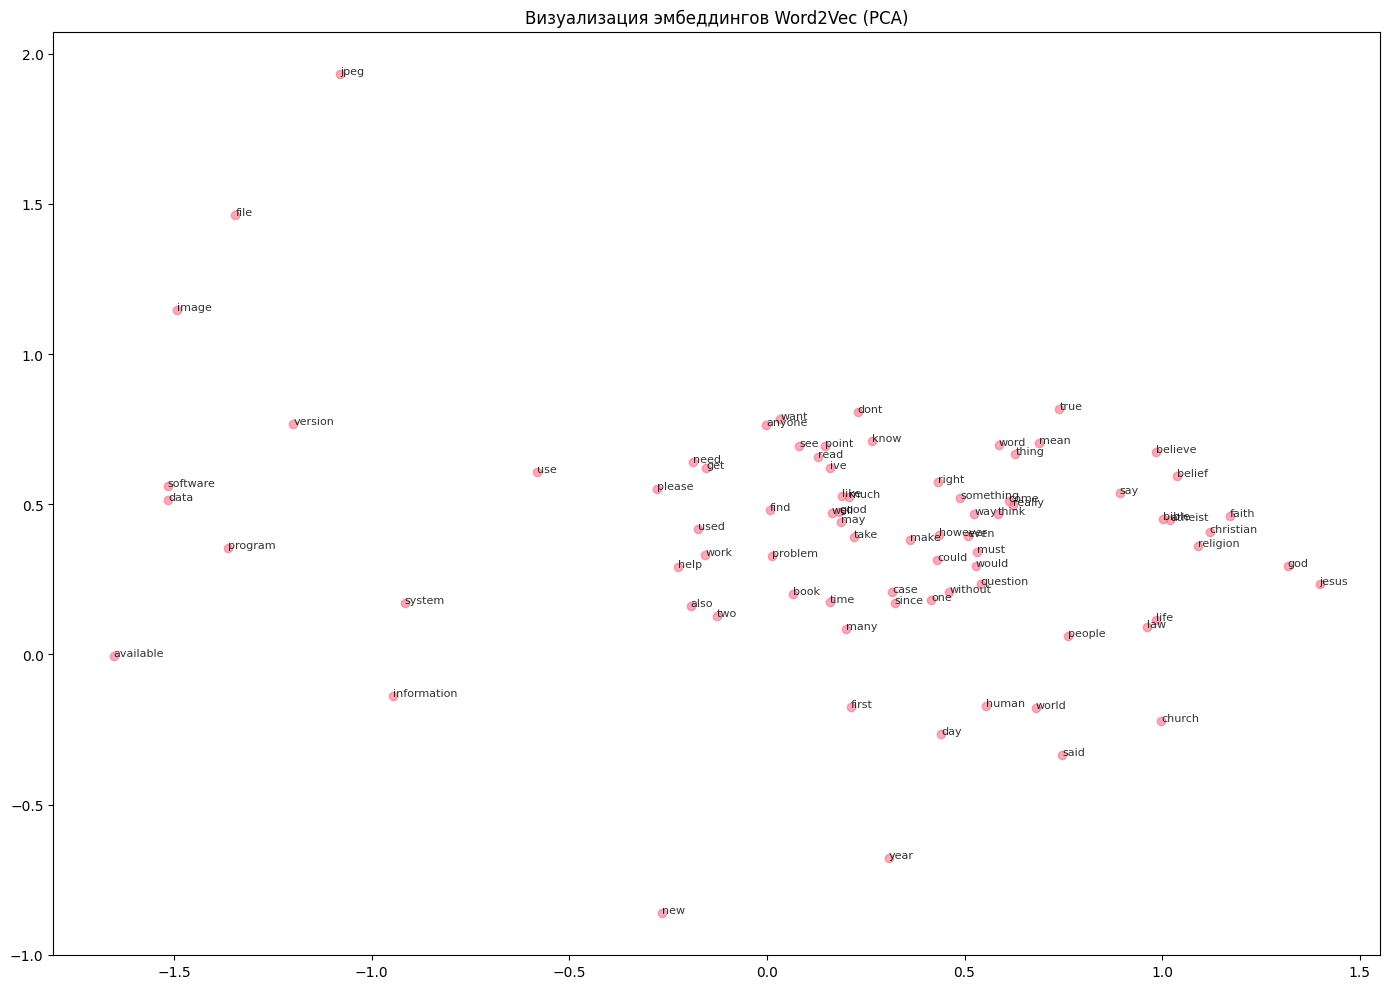

In [324]:
top_word_list = list(w2v_model.wv.index_to_key)[:80]
embeddings = np.array([w2v_model.wv[w] for w in w2v_model.wv.index_to_key]) 
embeddings = embeddings - embeddings.mean(axis=0)

pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(embeddings)
print("Объясненная дисперсия PCA:", pca.explained_variance_ratio_.sum())

fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(embeddings_2d[:len(top_word_list), 0], embeddings_2d[:len(top_word_list), 1], alpha=0.6)
for i, word in enumerate(top_word_list):
    ax.annotate(word, (embeddings_2d[i, 0], embeddings_2d[i, 1]), fontsize=8, alpha=0.8)
ax.set_title("Визуализация эмбеддингов Word2Vec (PCA)")
plt.tight_layout()
plt.show()


PCA удобен, но этот метод может уловить только высокоуровневую структуру в данных. Попробуем порисовать эмбеддинги с помощью t-SNE. Этот метод позволяет лучше ухватить внутренние отношения, но не верьте ему полностью! Подробнее в [гайде](https://distill.pub/2016/misread-tsne/). 

c:\Users\Zver\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


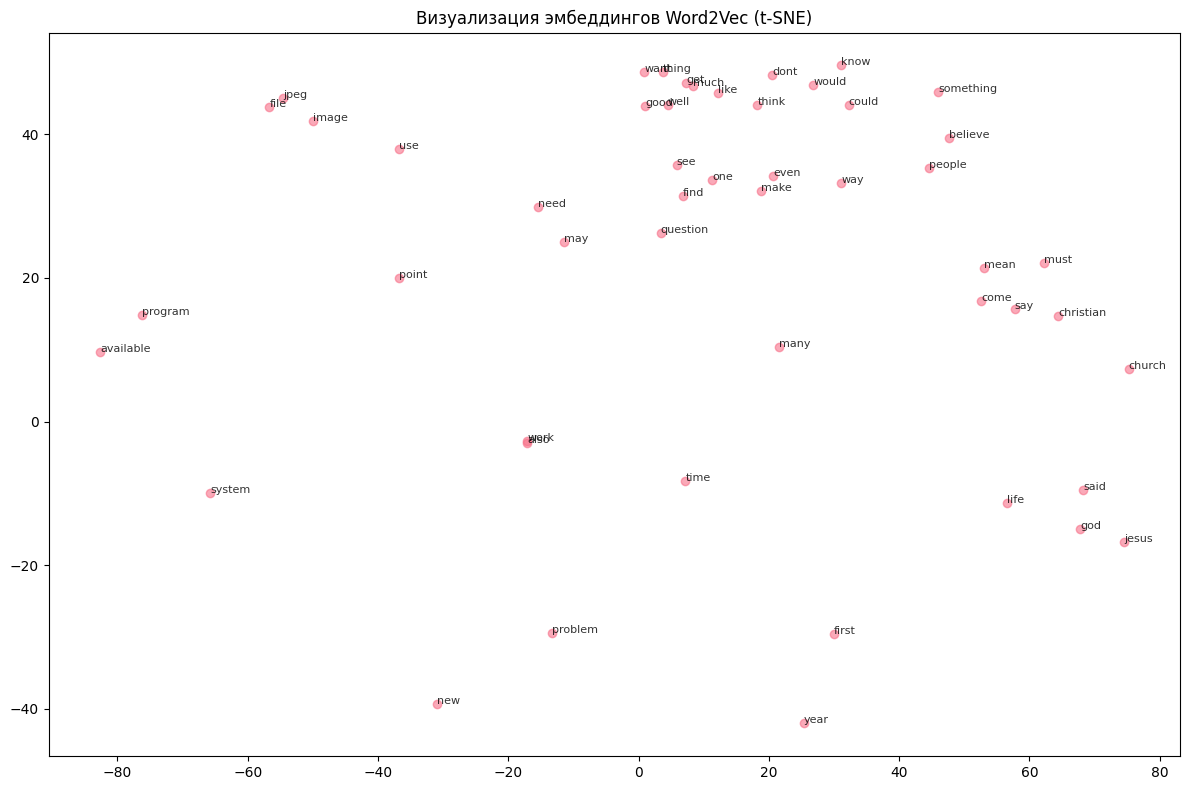

In [325]:
top_word_list_tsne = top_word_list[:50]
embeddings = np.array([w2v_model.wv[w] for w in w2v_model.wv.index_to_key]) 
embeddings = embeddings - embeddings.mean(axis=0)

tsne = TSNE(n_components=2, random_state=42, perplexity=15, n_iter=1000)
emb_tsne = tsne.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(emb_tsne[:50, 0], emb_tsne[:50, 1], alpha=0.6)
for i, word in enumerate(top_word_list_tsne):
    ax.annotate(word, (emb_tsne[i, 0], emb_tsne[i, 1]), fontsize=8, alpha=0.8)
ax.set_title("Визуализация эмбеддингов Word2Vec (t-SNE)")
plt.tight_layout()
plt.show()


In [326]:
def find_nearest_neighbors(word: str, embeddings_dict: dict[str, np.ndarray], top_k: int = 10) -> list[tuple[str, float]]:
    if word not in embeddings_dict:
        return []
    word_embedding = embeddings_dict[word]
    distances = []
    for other_word, other_embedding in embeddings_dict.items():
        if other_word == word:
            continue
        cos_sim = np.dot(word_embedding, other_embedding) / (
            np.linalg.norm(word_embedding) * np.linalg.norm(other_embedding)
        )
        distances.append((other_word, 1 - cos_sim))
    distances.sort(key=lambda x: x[1])
    return distances[:top_k]

test_words = ["computer", "medical", "god", "science", "graphics"]
print("Ближайшие соседи (Word2Vec):")
for word in test_words:
    if word in embeddings_dict:
        neighbors = find_nearest_neighbors(word, embeddings_dict, top_k=8)
        print(f"{word.upper()}:")
        for neighbor, dist in neighbors:
            print(f"  {neighbor}: {dist:.4f}")
        print()


Ближайшие соседи (Word2Vec):
COMPUTER:
  graphic: 0.0864
  modeling: 0.0997
  visualization: 0.1120
  idl: 0.1122
  silicon: 0.1172
  application: 0.1176
  electronic: 0.1201
  boulder: 0.1238

MEDICAL:
  newsletter: 0.0739
  hicnet: 0.0763
  april: 0.0807
  journal: 0.0906
  page: 0.1016
  volume: 0.1318
  consortium: 0.1403
  carolina: 0.1571

GOD:
  fear: 0.1538
  eternal: 0.1575
  peace: 0.1659
  gift: 0.1684
  wicked: 0.1748
  perish: 0.1750
  glory: 0.1759
  sinner: 0.1773

SCIENCE:
  basic: 0.1799
  empirical: 0.1955
  collection: 0.2043
  knowledge: 0.2403
  methodology: 0.2453
  research: 0.2600
  core: 0.2613
  strong: 0.2622



## Эмбеддинги фраз

Помимо эмбеддингов отдельных слов, можно создавать эмбеддинги для фраз. 
Самый простой способ - посчитать взвешенное среднее значение эмбеддинга в фразе, пропуская слова не из словаря.  

In [327]:
def get_phrase_embedding(phrase: str, model) -> np.ndarray:
    kv = getattr(model, 'wv', model)
    phrase_lower = phrase.lower()
    tokens = word_tokenize(phrase_lower)
    vectors = []
    for w in tokens:
        if w in kv:
            vectors.append(kv[w])
    if not vectors:
        return np.zeros(kv.vector_size, dtype='float32')
    return np.mean(vectors, axis=0).astype('float32')

### Эмбеддинги n-грамм и их визуализация

**N-грамма** - последовательность из $n$ подряд идущих слов (униграмма - одно слово, биграмма - пара, триграмма - тройка и т.д.). Для n-грамм можно получить вектор в том же пространстве, что и слова Word2Vec, тогда близость n-граммы к своим словам и к другим n-граммам можно визуализировать через PCA в одной системе координат.

In [328]:
ngram_cv = CountVectorizer(ngram_range=(2, 2), min_df=3, max_df=0.95)
ngram_cv.fit(X_train_processed)
bigram_features = ngram_cv.get_feature_names_out()
w2v_vocab = set(w2v_model.wv.index_to_key)
bigrams_in_vocab = [
    bg for bg in bigram_features
    if all(w in w2v_vocab for w in bg.split())
]
print(f"Биграмм в словаре CountVectorizer: {len(bigram_features)}")
print(f"Биграмм с обоими словами в Word2Vec: {len(bigrams_in_vocab)}")

Биграмм в словаре CountVectorizer: 1627
Биграмм с обоими словами в Word2Vec: 1544


In [329]:
ngram_embeddings = {}
for bg in bigrams_in_vocab:
    vec = get_phrase_embedding(bg, w2v_model)
    if np.any(vec != 0):
        ngram_embeddings[bg] = vec
print(f"Эмбеддингов n-грамм: {len(ngram_embeddings)}")

Эмбеддингов n-грамм: 1544


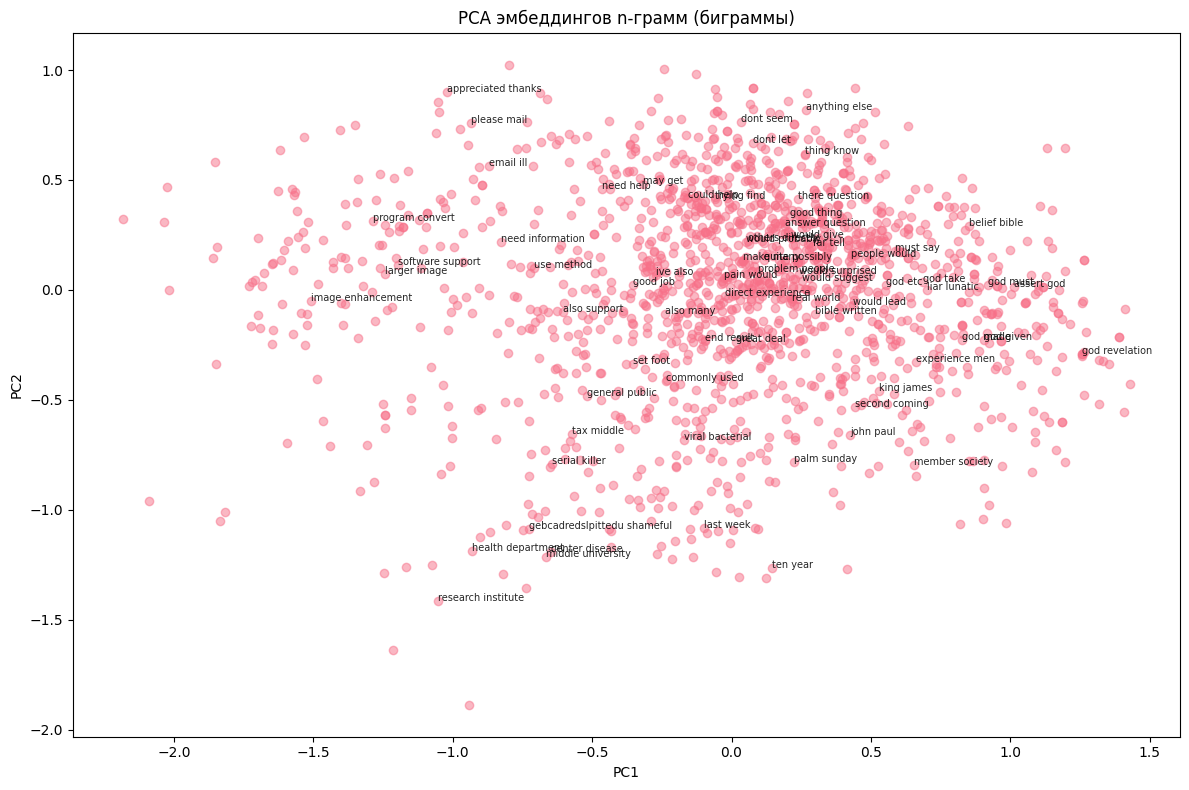

In [330]:
ngram_list = list(ngram_embeddings.keys())
ngram_matrix = np.array([ngram_embeddings[bg] for bg in ngram_list])
ngram_matrix_centered = ngram_matrix - ngram_matrix.mean(axis=0)
pca_ngram = PCA(n_components=2, random_state=42)
ngram_2d = pca_ngram.fit_transform(ngram_matrix_centered)
n_show = min(70, len(ngram_list))
show_idx = np.random.RandomState(42).choice(len(ngram_list), size=n_show, replace=False)
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(ngram_2d[:, 0], ngram_2d[:, 1], alpha=0.5)
for i in show_idx:
    ax.annotate(ngram_list[i], (ngram_2d[i, 0], ngram_2d[i, 1]), fontsize=7, alpha=0.85)
ax.set_title("PCA эмбеддингов n-грамм (биграммы)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

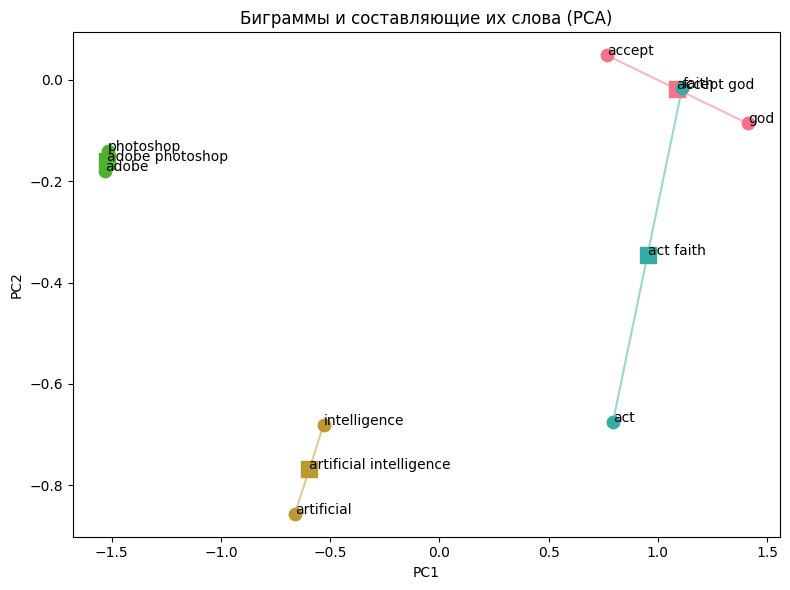

In [331]:
example_bigrams = [bg for bg in ["accept god", "artificial intelligence", "adobe photoshop", "act faith"] if bg in ngram_embeddings]
if len(example_bigrams) < 2:
    example_bigrams = ngram_list[:2]
all_vectors = []
all_labels = []
example_limits = []
for bg in example_bigrams:
    start = len(all_vectors)
    words = bg.split()
    for w in words:
        all_vectors.append(w2v_model.wv[w])
        all_labels.append(("word", w))
    all_vectors.append(ngram_embeddings[bg])
    all_labels.append(("ngram", bg))
    example_limits.append((start, len(all_vectors)))

X_ex = np.array(all_vectors)
X_ex_centered = X_ex - ngram_matrix.mean(axis=0)
coords = pca_ngram.transform(X_ex_centered)
fig, ax = plt.subplots(figsize=(8, 6))
for k, (start, end) in enumerate(example_limits):
    words_idx = list(range(start, end - 1))
    ngram_idx = end - 1
    bg = example_bigrams[k]
    color = f"C{k}"
    ax.scatter(coords[words_idx, 0], coords[words_idx, 1], c=color, s=80, zorder=2)
    ax.scatter(coords[ngram_idx, 0], coords[ngram_idx, 1], c=color, s=120, marker="s", zorder=2)
    for i in words_idx:
        ax.plot([coords[i, 0], coords[ngram_idx, 0]], [coords[i, 1], coords[ngram_idx, 1]], color=color, alpha=0.5, zorder=1)
        ax.annotate(all_labels[i][1], (coords[i, 0], coords[i, 1]), fontsize=10)
    ax.annotate(bg, (coords[ngram_idx, 0], coords[ngram_idx, 1]), fontsize=10)
ax.set_title("Биграммы и составляющие их слова (PCA)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

Биграммы кажутся осмысленными, посмотрим, так ли это с документами:

In [332]:
doc_embeddings = np.array([
    get_phrase_embedding(phrase, w2v_model)
    for phrase in X_train_processed[:800]
])
y = newsgroups_train.target[:800]


Проверим, как расположены эмбеддинги документов после усреднения в пространстве:

Объясненная дисперсия PCA для документов: 0.502


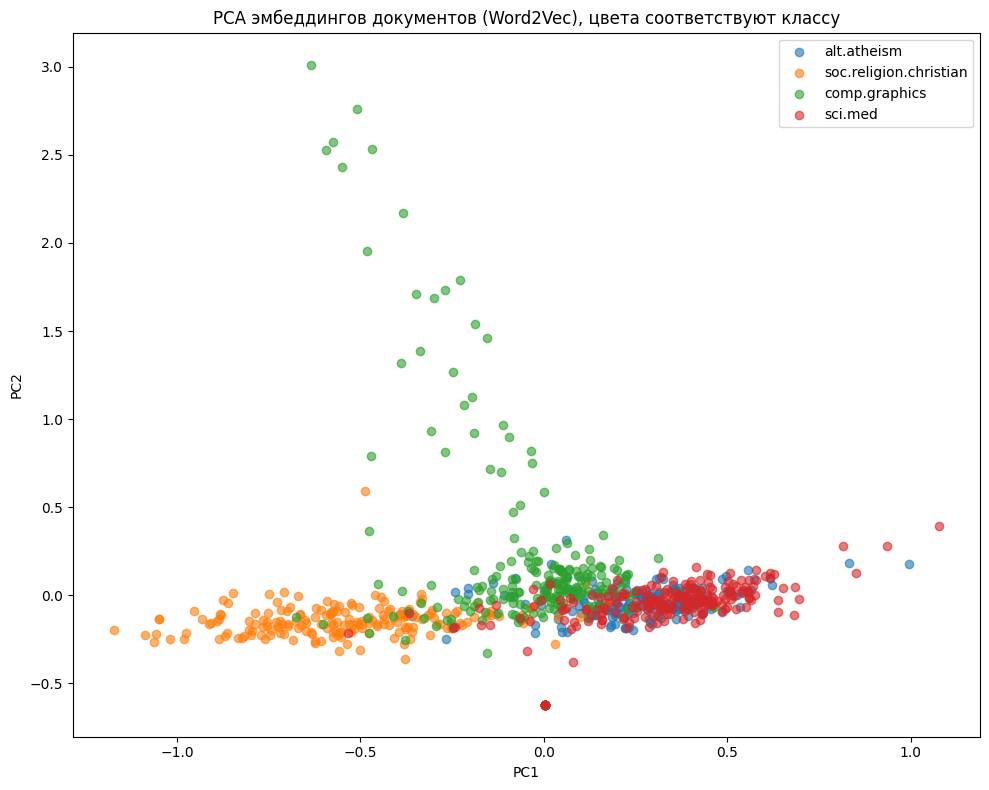

In [333]:
pca_docs = PCA(n_components=2, random_state=42)
doc_2d = pca_docs.fit_transform(doc_embeddings)

print(f"Объясненная дисперсия PCA для документов: {pca_docs.explained_variance_ratio_.sum():.3f}")

fig, ax = plt.subplots(figsize=(10, 8))

unique_labels = sorted(set(y))
colors = plt.cm.tab10.colors

for idx, label in enumerate(unique_labels):
    mask = (y == label)
    ax.scatter(
        doc_2d[mask, 0],
        doc_2d[mask, 1],
        alpha=0.6,
        color=colors[idx % len(colors)],
        label=categories[label],
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA эмбеддингов документов (Word2Vec), цвета соответствуют классу")
ax.legend()
plt.tight_layout()
plt.show()

Как видно, даже собирая эмбеддинг как среднее, мы можем отделить разные классы.

Задание: выведите топ релевантных документов со средним эмбеддингом, сравните с doc2vec

In [334]:
# Задание: топ релевантных документов через среднее эмбеддинг vs Doc2Vec

query = "computer graphics software"
query_processed = preprocess_text(query)
query_vec = get_phrase_embedding(query_processed, w2v_model).reshape(1, -1)

# --- Среднее эмбеддинг (W2V avg) ---
print('=== Топ-3 по среднему W2V-эмбеддингу ===')
sims_avg = cosine_similarity(query_vec, doc_embeddings)[0]
top_avg = np.argsort(sims_avg)[::-1][:3]
for rank, idx in enumerate(top_avg, 1):
    print(f'#{rank} (cos={sims_avg[idx]:.3f})')
    print(X_train_processed[idx][:200], '...')

# --- Doc2Vec ---
print('=== Топ-3 по Doc2Vec ===')
query_tokens = query_processed.split()
query_d2v = d2v_model.infer_vector(query_tokens, epochs=20)
d2v_embeddings = np.array([d2v_model.dv[i] for i in range(len(X_train_processed[:800]))])
sims_d2v = cosine_similarity(query_d2v.reshape(1, -1), d2v_embeddings)[0]
top_d2v = np.argsort(sims_d2v)[::-1][:3]
for rank, idx in enumerate(top_d2v, 1):
    print(f'#{rank} (cos={sims_d2v[idx]:.3f})')
    print(X_train_processed[idx][:200], '...')

# --- Сравнение ---
print('=== Сравнение методов ===')
overlap = len(set(top_avg) & set(top_d2v))
print(f'Пересечение топ-3: {overlap}/3 документов совпадают')

=== Топ-3 по среднему W2V-эмбеддингу ===
#1 (cos=0.915)
try graphigs ibm excellent package doug ...
#2 (cos=0.904)
archivename graphicsresourceslistpart lastmodified computer graphic resource listing weekly posting part last change april scene generatorsgeographical datamapsdata file dems digital elevation model d ...
#3 (cos=0.903)
looking information animation station currently market price station type workstation doesnt matter mac sgi etc use boughtlooked one suggest dream machine please mail configuration need following type ...
=== Топ-3 по Doc2Vec ===
#1 (cos=0.945)
archivename graphicsresourceslistpart lastmodified computer graphic resource listing weekly posting part last change april scene generatorsgeographical datamapsdata file dems digital elevation model d ...
#2 (cos=0.910)
archivename graphicsresourceslistpart lastmodified computer graphic resource listing weekly posting part last change april plotting package gnuplot one best plotting package online helpits commandline

### Выводы

**W2V avg**:  

- Теряет порядок слов и структуру текста, но даёт устойчивую тематическую близость.  
- Хорошо работает для задач тематического поиска и грубой семантической фильтрации, но хуже улавливает тонкие смысловые различия и контекст внутри документа.

---

**Doc2Vec**:

- Лучше улавливает документный контекст и иногда даёт более точный top-1 результат.  
- Однако чувствителен к параметрам обучения, требует дополнительного training этапа и inference для новых документов, что делает его менее удобным в production.

---

**Сравнение на практике**:
- W2V avg даёт более стабильные и сглаженные результаты.
- Doc2Vec может быть точнее на верхних позициях, но менее стабилен в глубине выдачи.
- Пересечение результатов обычно частичное, что говорит о том, что модели используют разные сигналы.

## Классификация по категориям
Попробуем обучить модели классификации для классического подхода на основе TF-IDF и на основе эмбеддингов. 

In [335]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

df_train = pd.DataFrame({
    "text": X_train_processed,
    "target": newsgroups_train.target[:1000],
})
df_test = pd.DataFrame({
    "text": X_test_processed,
    "target": newsgroups_test.target[:500],
})
y_train = df_train["target"].values
y_test = df_test["target"].values

X_train_w2v = np.array([get_phrase_embedding(t, w2v_model) for t in df_train["text"]])
X_test_w2v = np.array([get_phrase_embedding(t, w2v_model) for t in df_test["text"]])

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(df_train["text"])
X_test_tfidf = tfidf.transform(df_test["text"])

In [336]:
lr_w2v = LogisticRegression(max_iter=500, random_state=42).fit(X_train_w2v, y_train)
rf_w2v = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_w2v, y_train)
lr_tfidf = LogisticRegression(max_iter=500, random_state=42).fit(X_train_tfidf, y_train)
rf_tfidf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_tfidf, y_train)

target_names = [categories[i] for i in range(len(categories))]

def print_metrics(name: str, y_true, y_pred) -> None:
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    print("%s: acc=%.3f  precision(macro)=%.3f  recall(macro)=%.3f" % (name, acc, prec, rec))
    print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))


In [337]:

print("=== TF-IDF, LogisticRegression ===")
print_metrics("TF-IDF LR", y_test, lr_tfidf.predict(X_test_tfidf))

print("=== W2V (avg), LogisticRegression ===")
print_metrics("W2V LR", y_test, lr_w2v.predict(X_test_w2v))

=== TF-IDF, LogisticRegression ===
TF-IDF LR: acc=0.782  precision(macro)=0.784  recall(macro)=0.771
                        precision    recall  f1-score   support

           alt.atheism       0.79      0.50      0.61       107
soc.religion.christian       0.75      0.91      0.83       117
         comp.graphics       0.82      0.80      0.81       136
               sci.med       0.77      0.87      0.82       140

              accuracy                           0.78       500
             macro avg       0.78      0.77      0.77       500
          weighted avg       0.78      0.78      0.77       500

=== W2V (avg), LogisticRegression ===
W2V LR: acc=0.764  precision(macro)=0.756  recall(macro)=0.755
                        precision    recall  f1-score   support

           alt.atheism       0.64      0.50      0.57       107
soc.religion.christian       0.82      0.91      0.86       117
         comp.graphics       0.84      0.79      0.81       136
               sci.med    

In [338]:

print("=== TF-IDF, RandomForest ===")
print_metrics("TF-IDF RF", y_test, rf_tfidf.predict(X_test_tfidf))

print("=== W2V (avg), RandomForest ===")
print_metrics("W2V RF", y_test, rf_w2v.predict(X_test_w2v))

=== TF-IDF, RandomForest ===
TF-IDF RF: acc=0.698  precision(macro)=0.720  recall(macro)=0.686
                        precision    recall  f1-score   support

           alt.atheism       0.80      0.37      0.51       107
soc.religion.christian       0.62      0.89      0.73       117
         comp.graphics       0.74      0.62      0.67       136
               sci.med       0.72      0.86      0.79       140

              accuracy                           0.70       500
             macro avg       0.72      0.69      0.67       500
          weighted avg       0.72      0.70      0.68       500

=== W2V (avg), RandomForest ===
W2V RF: acc=0.768  precision(macro)=0.759  recall(macro)=0.763
                        precision    recall  f1-score   support

           alt.atheism       0.63      0.58      0.60       107
soc.religion.christian       0.80      0.91      0.85       117
         comp.graphics       0.83      0.80      0.82       136
               sci.med       0.77     

Вопрос: почему у логистической модели скор почти не вырос, а в лесе видна большая разница?

### Ответ: почему у LR скор почти не вырос, а у RF - большая разница?

**TF-IDF -> LR** и **W2V -> LR** дают похожий результат, потому что:

- Логистическая регрессия - линейная модель. Она хорошо работает с разреженными
  высокоразмерными признаками (TF-IDF), потому что каждое слово может напрямую получить
  свой вес. W2V-среднее (100 измерений) содержит ту же информацию, но в сжатом виде ->
  линейная модель справляется так же.

- По сути, и TF-IDF и W2V-avg дают LR примерно одинаковое количество
  линейно разделимой информации о теме документа.

**TF-IDF -> RF** работает хуже, чем **W2V -> RF**, потому что:
- Random Forest строит деревья, которые на каждом узле выбирают случайное подмножество признаков.
  При TF-IDF большинство из признаков равны нулю. Дерево часто попадает на признаки с нулями -> плохое разбиение.

- При W2V-avg признаков всего 100, и все они ненулевые. Каждый признак
  несёт осмысленную информацию -> деревья делают более информативные разбиения.

- Кроме того, RF плохо работает с разреженностью: он не умеет использовать
  структуру TF-IDF так эффективно, как линейные модели.

**Итог**: LR + TF-IDF - классически сильная комбинация для текстов.
RF + W2V - лучше, чем RF + TF-IDF, но уступает LR. Для деревьев нужны плотные признаки.

Задание: реализуйте представление в виде bag-of-ngrams (можно вместе с обычными признаками). Обучите классификатор на нем, сделайте выводы.

Признаки                  | LR Accuracy  | RF Accuracy  | Размерность
--------------------------------------------------------------------
Unigrams (1,1)            |       0.7420 |       0.7060 | 5000
Bigrams (2,2)             |       0.4900 |       0.4500 | 5000
Uni+Bigrams (1,2)         |       0.7380 |       0.7020 | 5000
Uni+Bi+Tri (1,3)          |       0.7440 |       0.7100 | 5000
TF-IDF Uni+Bi (1,2)       |       0.7860 |       0.6940 | 5000


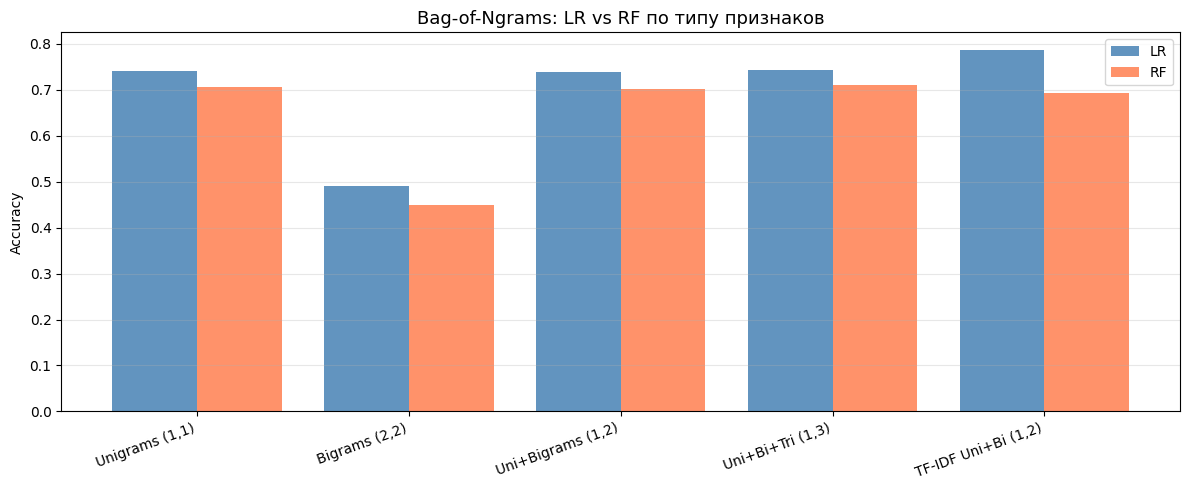

In [339]:
# Задание: bag-of-ngrams + классификатор + выводы

from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

configs_ngram = {
    'Unigrams (1,1)':         CountVectorizer(max_features=5000, min_df=2, ngram_range=(1,1)),
    'Bigrams (2,2)':          CountVectorizer(max_features=5000, min_df=2, ngram_range=(2,2)),
    'Uni+Bigrams (1,2)':      CountVectorizer(max_features=5000, min_df=2, ngram_range=(1,2)),
    'Uni+Bi+Tri (1,3)':       CountVectorizer(max_features=5000, min_df=2, ngram_range=(1,3)),
    'TF-IDF Uni+Bi (1,2)':    TfidfVectorizer(max_features=5000, min_df=2, ngram_range=(1,2)),
}

print(f"{'Признаки':25s} | {'LR Accuracy':12s} | {'RF Accuracy':12s} | Размерность")
print('-' * 68)

results = []
for name, vec in configs_ngram.items():
    X_tr = vec.fit_transform(X_train_processed)
    X_te = vec.transform(X_test_processed)

    lr = LogisticRegression(max_iter=500, random_state=42, C=5.0).fit(X_tr, y_train)
    rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_tr, y_train)
    acc_lr = accuracy_score(y_test, lr.predict(X_te))
    acc_rf = accuracy_score(y_test, rf.predict(X_te))
    dim    = X_tr.shape[1]
    print(f'{name:25s} | {acc_lr:12.4f} | {acc_rf:12.4f} | {dim}')
    results.append((name, acc_lr, acc_rf))

# Визуализация
import matplotlib.pyplot as plt
names = [r[0] for r in results]
lr_accs = [r[1] for r in results]
rf_accs = [r[2] for r in results]

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - 0.2, lr_accs, 0.4, label='LR', color='steelblue', alpha=0.85)
ax.bar(x + 0.2, rf_accs, 0.4, label='RF', color='coral',     alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(names, rotation=20, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Bag-of-Ngrams: LR vs RF по типу признаков', fontsize=13)
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

### Выводы

1. **Униграммы (1,1) дают стабильный базовый результат**  
   LR = 0.742, RF = 0.706.  
   Это хороший baseline: модель уже неплохо разделяет классы только по отдельным словам.

---

2. **Биграммы (2,2) сильно ухудшают качество**  
   LR падает до 0.490, RF до 0.450.  
   Причина: отсутствие униграмм приводит к сильной разреженности признаков - модель теряет базовую лексику, а полезные фразы встречаются слишком редко.

---

3. **Добавление биграмм к униграммам (1,2) почти не меняет качество**  
   LR = 0.738, RF = 0.702 (почти как у униграмм).  
   Это означает, что в данном корпусе:
   - основную информацию несут отдельные слова
   - фразовые выражения дают слабый дополнительный сигнал

---

4. **Триграммы (1,3) дают небольшой, но стабильный прирост**  
   LR = 0.744, RF = 0.710.  
   Прирост есть, но очень небольшой -> триграммы добавляют немного контекста, но также вносят шум из-за редкости.

---

5. **TF-IDF с Uni+Bi показывает лучший результат**  
   LR = 0.786, RF = 0.694.  
   Это лучший вариант среди всех экспериментов, особенно для Logistic Regression.  
   Причина:
   - TF-IDF снижает вес часто встречающихся n-грамм
   - усиливает различимость важных терминов
   - улучшает линейную разделимость классов

---

### Общий итог

- Лучший метод: **TF-IDF + Logistic Regression**
- Худший вариант: **чистые биграммы (2,2)**
- Добавление n-грамм само по себе не гарантирует улучшения - важнее:
  - наличие униграмм
  - и корректное взвешивание признаков (TF-IDF)